In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from tqdm import tqdm
import os

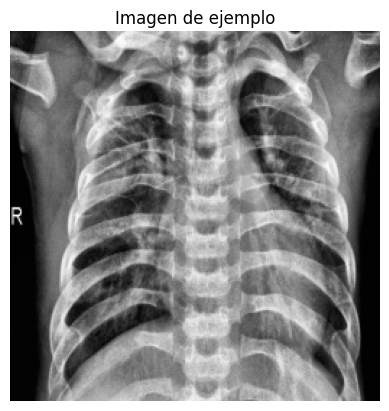

In [2]:
example_path = "../data/Train/PNEUMONIA/person1001_bacteria_2932_92394105.jpg"
img = cv2.imread(example_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Imagen de ejemplo")
plt.axis("off")
plt.show()


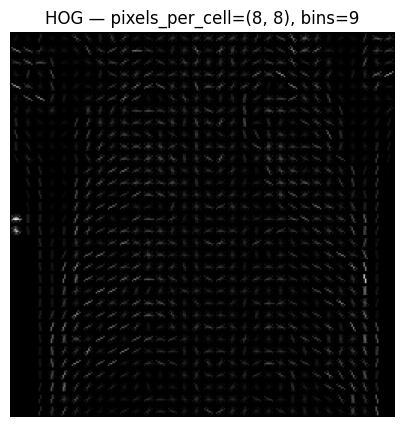

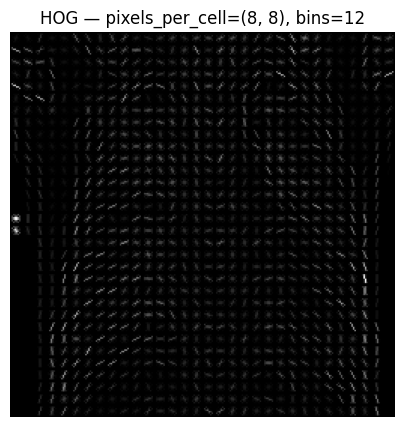

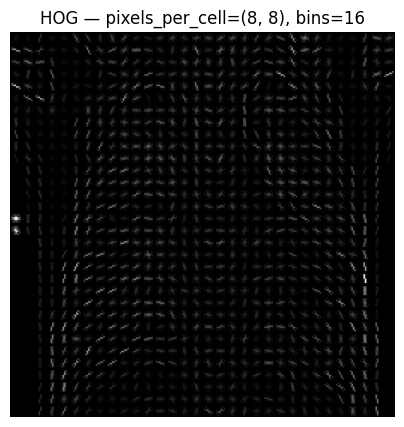

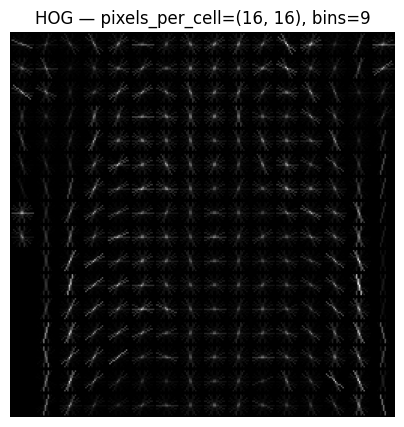

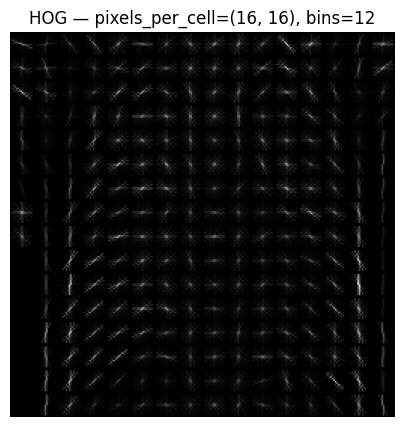

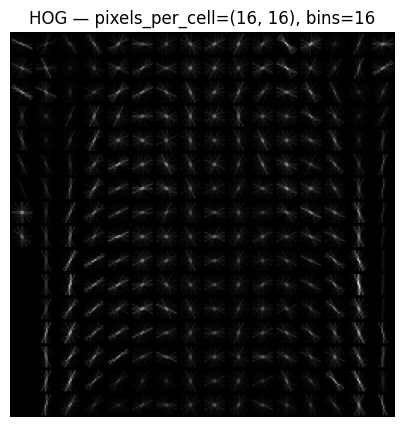

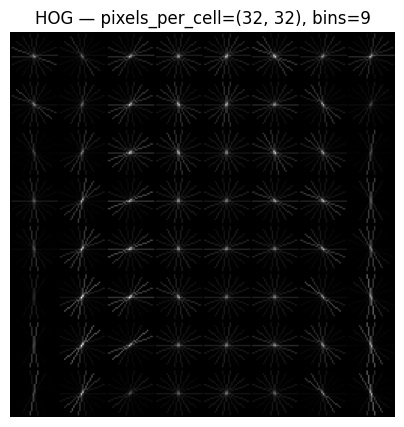

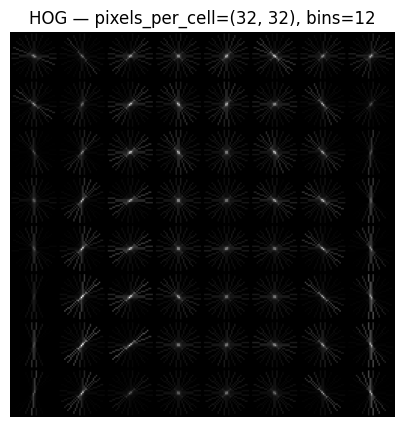

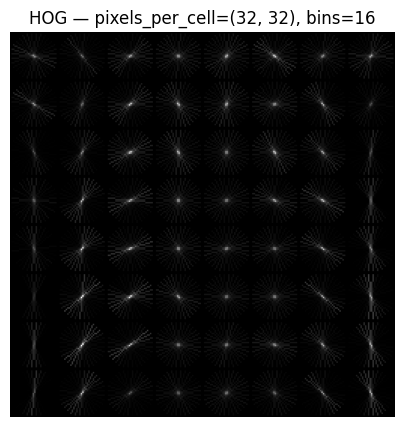

In [3]:
def descriptor_hog(img, orientations=9, pixels_per_cell=(16,16)):
    feat, hog_img = hog(
        img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=True
    )
    return feat, hog_img

pixel_options = [(8,8), (16,16), (32,32)]
bin_options = [9, 12, 16]

for pix in pixel_options:
    for bins in bin_options:
        _, hog_img = descriptor_hog(img, orientations=bins, pixels_per_cell=pix)
        plt.figure(figsize=(5,5))
        plt.imshow(hog_img, cmap="gray")
        plt.title(f"HOG — pixels_per_cell={pix}, bins={bins}")
        plt.axis("off")
        plt.show()


In [4]:
def descriptor_hu(img):
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()
    return hu

hu = descriptor_hu(img)
for i, v in enumerate(hu):
    print(f"Hu[{i}] = {v}")


Hu[0] = 0.0012771020681901827
Hu[1] = 4.052055487718773e-08
Hu[2] = 3.745547392919188e-11
Hu[3] = 1.8312980341240394e-12
Hu[4] = 1.0280887448000521e-23
Hu[5] = 4.934313361647e-17
Hu[6] = -1.1150674427981367e-23


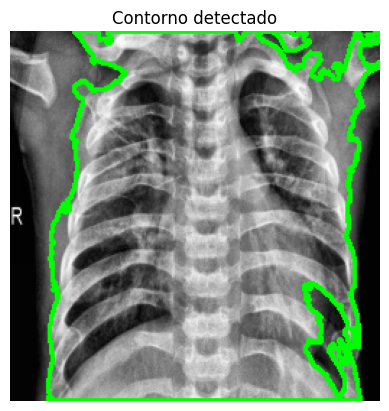

In [5]:
def segmentar(img):
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def descriptor_contorno(img):
    th = segmentar(img)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return np.array([0,0,0,0])

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perim = cv2.arcLength(cnt, True)
    circularity = (4 * np.pi * area / (perim**2)) if perim != 0 else 0

    if len(cnt) >= 5:
        (x,y),(MA,ma),angle = cv2.fitEllipse(cnt)
        eccentricity = np.sqrt(1 - (MA/ma)**2)
    else:
        eccentricity = 0

    return np.array([area, perim, circularity, eccentricity])

th = segmentar(img)
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_color, [cnt], -1, (0,255,0), 2)

plt.imshow(img_color[...,::-1])
plt.title("Contorno detectado")
plt.axis("off")
plt.show()



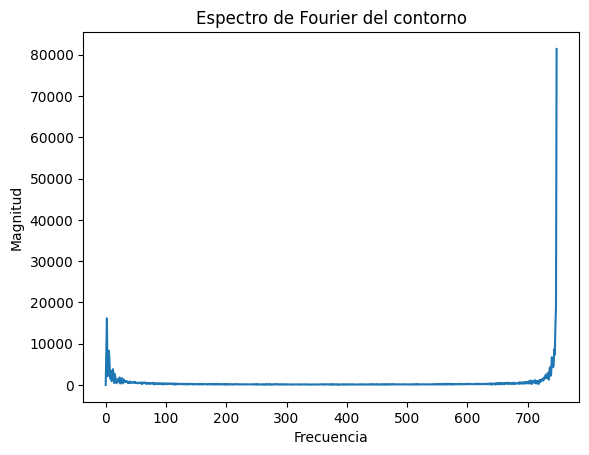

In [6]:
def descriptor_fourier(img, n_coeffs=20):
    # 1. Segmentación por Otsu
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Si no hay contornos → vector vacío
    if len(contours) == 0:
        return np.zeros(2*n_coeffs)

    # 2. Elegir contorno más grande
    cnt = max(contours, key=cv2.contourArea)
    c = np.squeeze(cnt)

    # Validar forma (N,2)
    if c.ndim != 2 or c.shape[0] < 10:
        return np.zeros(2*n_coeffs)

    # 3. Serie compleja
    complex_contour = c[:,0] + 1j * c[:,1]

    # Remover componente DC → invariancia a traslación
    complex_contour = complex_contour - complex_contour.mean()

    # 4. Transformada
    fourier = np.fft.fft(complex_contour)

    # 5. Normalización por el primer coef. no nulo → invariancia de escala
    ref = np.abs(fourier[1])
    if ref == 0:
        ref = 1
    fourier_norm = fourier / ref

    # 6. Tomar primeros N coeficientes
    coeffs = fourier_norm[:n_coeffs]

    # 7. Concatenar real + imaginario → feature vector final
    fsd_vec = np.concatenate([np.real(coeffs), np.imag(coeffs)])

    return fsd_vec

# Para visualizar el espectro Fourier del contorno

# 1. Segmentar
_, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("No se encontraron contornos.")
else:
    cnt = max(contours, key=cv2.contourArea)
    c = np.squeeze(cnt)

    if c.ndim == 2 and c.shape[0] >= 10:
        complex_contour = c[:,0] + 1j * c[:,1]
        complex_contour = complex_contour - complex_contour.mean()

        fourier = np.fft.fft(complex_contour)

        # Mostrar espectro
        plt.plot(np.abs(fourier))
        plt.title("Espectro de Fourier del contorno")
        plt.xlabel("Frecuencia")
        plt.ylabel("Magnitud")
        plt.show()
    else:
        print("Contorno demasiado pequeño o inválido.")




In [7]:
def extract_descriptors(img, n_fourier=20):
    hog_feat, _ = descriptor_hog(img)
    hu_feat = descriptor_hu(img)
    cnt_feat = descriptor_contorno(img)
    fourier_feat = descriptor_fourier(img, n_coeffs=n_fourier)

    return np.concatenate([hog_feat, hu_feat, cnt_feat, fourier_feat])

def process_dataset(root_dir):
    X = []
    y = []
    classes = os.listdir(root_dir)

    for label in classes:
        folder = os.path.join(root_dir, label)
        images = os.listdir(folder)

        print(f"Procesando {label} ({len(images)} imágenes)")

        for fname in tqdm(images):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            feats = extract_descriptors(img)
            X.append(feats)
            y.append(label)

    return np.array(X), np.array(y)



In [21]:
train_dir = "../data/Train"
val_dir = "../data/Val"
test_dir = "../data/Test"

X_train, y_train = process_dataset(train_dir)
X_val, y_val = process_dataset(val_dir)
X_test, y_test = process_dataset(test_dir)

Procesando PNEUMONIA (2991 imágenes)


100%|██████████| 2991/2991 [01:13<00:00, 40.52it/s]


Procesando NORMAL (1108 imágenes)


100%|██████████| 1108/1108 [00:27<00:00, 39.64it/s]


Procesando PNEUMONIA (641 imágenes)


...

100%|██████████| 237/237 [00:05<00:00, 40.31it/s]


Procesando PNEUMONIA (641 imágenes)


100%|██████████| 641/641 [00:16<00:00, 39.04it/s]


Procesando NORMAL (238 imágenes)


100%|██████████| 238/238 [00:06<00:00, 39.23it/s]


In [11]:
np.save("X_train_2A.npy", X_train)
np.save("y_train_2A.npy", y_train)

np.save("X_val_2A.npy", X_val)
np.save("y_val_2A.npy", y_val)

np.save("X_test_2A.npy", X_test)
np.save("y_test_2A.npy", y_test)


#Parte 2B

In [8]:
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.filters import gabor
from scipy.stats import skew, kurtosis
from skimage import img_as_ubyte

##1. Local Binary Patterns (LBP):

El método se reconoce como un descriptor de textura ampliamente empleado en el procesamiento de imágenes y fue concebido originalmente para caracterizar patrones en imágenes en escala de grises. En este contexto específico, resulta particularmente útil para identificar variaciones texturales en radiografías, lo que facilita las tareas de clasificación y el procesamiento posterior de la imagen de entrada.

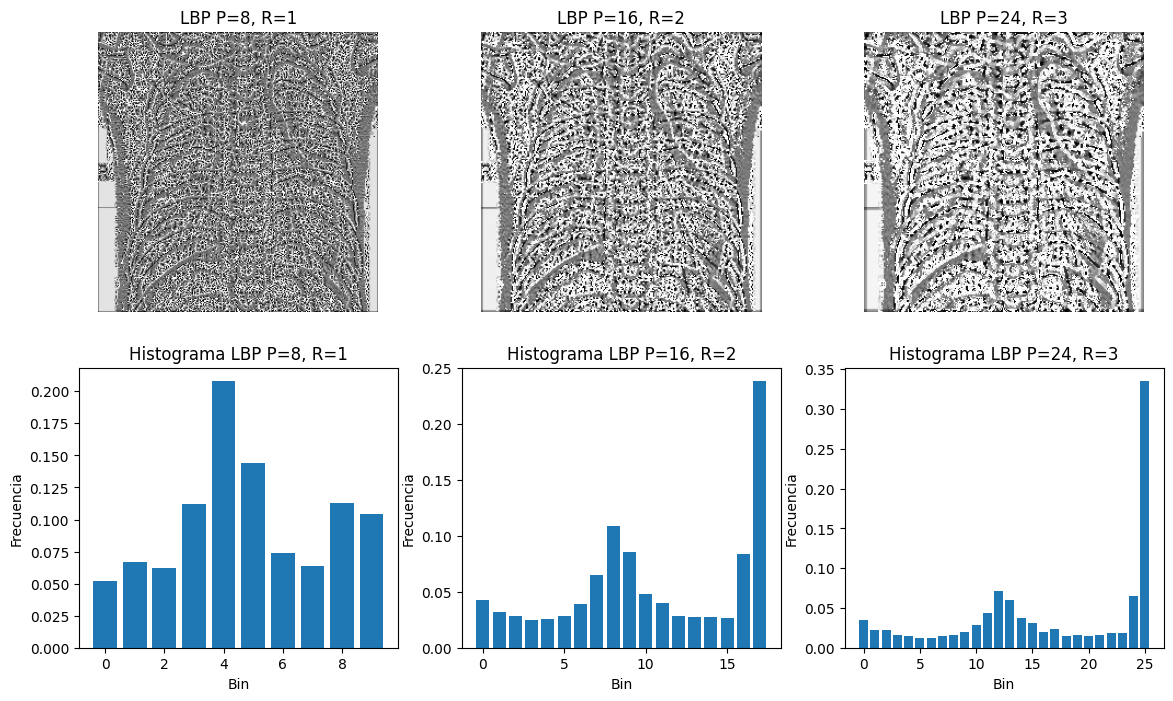

In [9]:
def descriptor_lbp(img, P=8, R=1, method="uniform"):
    """
    img : imagen en escala de grises (0–255)
    P        : número de puntos vecinos
    R        : radio
    method   : 'uniform' recomendado para reducir dimensión
    """
    lbp = local_binary_pattern(img, P, R, method=method)

    # Número de bins para el histograma
    if method == "uniform":
        n_bins = P + 2
    else:
        n_bins = int(lbp.max() + 1)

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    return hist, lbp


# ===== Ejemplo de experimentación con diferentes radios y puntos =====
# Utilizando la imagen previamente cargada


parametros_lbp = [
    (8, 1),
    (16, 2),
    (24, 3),
]

plt.figure(figsize=(14, 8))
for i, (P, R) in enumerate(parametros_lbp, 1):
    hist_lbp, lbp_img = descriptor_lbp(img, P=P, R=R, method="uniform")

    plt.subplot(2,len(parametros_lbp),i)
    plt.title(f"LBP P={P}, R={R}")
    plt.imshow(lbp_img, cmap='gray')
    plt.axis('off')


    plt.subplot(2, len(parametros_lbp), i+ len(parametros_lbp))
    plt.bar(np.arange(len(hist_lbp)), hist_lbp)
    plt.title(f"Histograma LBP P={P}, R={R}")
    plt.xlabel("Bin")
    plt.ylabel("Frecuencia")


plt.show()


# Comentarios a partir de los resultados de Local Binary Patterns

Se observa que a  mayor radio (R), se capturan patrones más globales. Así mismo, cuando se tiene un mayor número de puntos (P), se obtienen descriptores más detallados.

## 2 Gray Level Co-occurrence Matriz (GLCM).

Es un descriptor de textura que analiza las relaciones entre pares de píxeles dentro de una imagen. A diferencia de los Local Binary Patterns, que evalúan la intensidad de cada píxel de manera individual, la matriz GLCM examina cómo se comportan pares de píxeles separados por una distancia y dirección determinadas. Este enfoque resulta especialmente útil para caracterizar lesiones o estructuras anatómicas en radiografías y otros estudios médicos.

In [10]:
def descriptor_glcm(
    img,
    distances=(1, 2, 3),
    angles=(0, np.pi/4, np.pi/2, 3*np.pi/4),
    levels=256
):
    """
    Devuelve un vector con:
    [contraste, correlación, energía, homogeneidad] para cada
    combinación distancia–ángulo concatenada.
    """
    # Asegurar tipo entero 0–levels-1
    img_uint = img_as_ubyte(img)
    glcm = graycomatrix(
        img_uint,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    props = ["contrast", "correlation", "energy", "homogeneity"]
    feats = []

    for prop in props:
        vals = graycoprops(glcm, prop)  # shape: (len(distances), len(angles))
        feats.extend(vals.ravel())

    return np.array(feats)


# ===== Ejemplo de prueba con distintas distancias y direcciones =====
distancias = [1, 2, 4]
angulos = [0, np.pi/4, np.pi/2, 3*np.pi/4]

glcm_feats = descriptor_glcm(img, distances=distancias, angles=angulos)
print("Dimensión del vector GLCM:", glcm_feats.shape[0])
print("Primeros valores GLCM:", glcm_feats[:10])


Dimensión del vector GLCM: 48
Primeros valores GLCM: [ 232.50997243  375.72525952  203.61104473  376.92618224  614.63459646
  375.72525952  549.07348056  376.92618224 1397.60187252 1464.70501023]


## 3.Filtros de Gabor

Es un filtro lineal sensible tanto a la frecuencia espacial como a la orientación, cuyo comportamiento se asemeja a la forma en que las neuronas de la corteza visual humana responden a bordes y patrones texturales. Debido a estas propiedades, se utiliza ampliamente en la clasificación de imágenes médicas —como radiografías, tomografías (TAC) y resonancias magnéticas (RMN)—, así como en tareas de segmentación basadas en componentes frecuenciales.

In [11]:
def descriptor_gabor(
    img,
    frequencies=(0.1, 0.2, 0.3),
    thetas=(0, np.pi/4, np.pi/2, 3*np.pi/4)
):
    """
    Aplica un banco de filtros de Gabor y devuelve para cada
    (frecuencia, theta) la media y desviación estándar de la magnitud.
    """
    img_float = img.astype(np.float32) / 255.0
    feats = []

    for theta in thetas:
        for freq in frequencies:
            real, imag = gabor(img_float, frequency=freq, theta=theta)
            magnitude = np.sqrt(real**2 + imag**2)

            feats.append(magnitude.mean())
            feats.append(magnitude.std())

    return np.array(feats)


# ===== Implementacion =====
freqs = (0.1, 0.2, 0.3)
thetas = (0, np.pi/4, np.pi/2, 3*np.pi/4)

gabor_feats = descriptor_gabor(img, frequencies=freqs, thetas=thetas)
print("Dimensión del vector Gabor:", gabor_feats.shape[0])
print("Primeros valores Gabor:", gabor_feats[:10])


Dimensión del vector Gabor: 24
Primeros valores Gabor: [0.01413554 0.01119636 0.00872251 0.00924229 0.00645588 0.00731476
 0.00976702 0.00903236 0.00665514 0.00708226]


## 4. Estadísticos de Primer Orden

In [12]:
def descriptor_primer_orden(img):
    """
    Calcula: media, varianza, skewness, kurtosis y entropía
    de los niveles de gris.
    """
    pixels = img.ravel().astype(np.float32)

    # Media y varianza
    mean_val = pixels.mean()
    var_val = pixels.var()

    # Skewness y kurtosis
    skew_val = skew(pixels)
    kurt_val = kurtosis(pixels)

    # Entropía (a partir del histograma normalizado)
    hist, _ = np.histogram(pixels, bins=256, range=(0, 256), density=True)
    hist_nonzero = hist[hist > 0]
    entropy_val = -np.sum(hist_nonzero * np.log2(hist_nonzero))

    return np.array([mean_val, var_val, skew_val, kurt_val, entropy_val])


# ===== Ejemplo de uso =====
first_order_feats = descriptor_primer_orden(img)
print("Estadísticas de primer orden (media, var, skew, kurt, entropía):")
print(first_order_feats)


Estadísticas de primer orden (media, var, skew, kurt, entropía):
[ 1.17714828e+02  3.69409180e+03 -2.86084712e-01 -7.15224504e-01
  7.63537550e+00]


## Presentación Integrada de los Descriptores

In [13]:
def extract_descriptors_completo(
    img,
    n_fourier=20,
    lbp_P=8,
    lbp_R=1,
    glcm_distances=(1, 2, 3),
    glcm_angles=(0, np.pi/4, np.pi/2, 3*np.pi/4),
    gabor_freqs=(0.1, 0.2, 0.3),
    gabor_thetas=(0, np.pi/4, np.pi/2, 3*np.pi/4)
):
    # Descriptores que ya tienes
    hog_feat, _ = descriptor_hog(img)
    hu_feat = descriptor_hu(img)
    fourier_feat = descriptor_fourier(img, n_coeffs=n_fourier)

    # Nuevos descriptores de textura
    lbp_hist, _ = descriptor_lbp(img, P=lbp_P, R=lbp_R, method="uniform")
    glcm_feat = descriptor_glcm(img, distances=glcm_distances, angles=glcm_angles)
    gabor_feat = descriptor_gabor(img, frequencies=gabor_freqs, thetas=gabor_thetas)
    first_order_feat = descriptor_primer_orden(img)

    # Concatenar todo en un solo vector
    feat_vector = np.concatenate([
        hog_feat,
        hu_feat,
        fourier_feat,
        lbp_hist,
        glcm_feat,
        gabor_feat,
        first_order_feat
    ])

    return feat_vector


In [14]:
print(extract_descriptors_completo(img).shape)

(8234,)


### Estructura y tamaño de cada Subdescriptor

In [15]:
def visualizar_dimensiones_descriptor():
    img1 = img  # Usa una imagen cualquiera cargada antes

    hog_feat, _ = descriptor_hog(img1)
    hu_feat = descriptor_hu(img1)
    fourier_feat = descriptor_fourier(img1)
    lbp_hist, _ = descriptor_lbp(img1)
    glcm_feat = descriptor_glcm(img1)
    gabor_feat = descriptor_gabor(img1)
    first_order_feat = descriptor_primer_orden(img1)

    print("HOG:              ", hog_feat.shape)
    print("Hu Moments:       ", hu_feat.shape)
    print("Fourier:          ", fourier_feat.shape)
    print("LBP histogram:    ", lbp_hist.shape)
    print("GLCM features:    ", glcm_feat.shape)
    print("Gabor features:   ", gabor_feat.shape)
    print("First-order stats:", first_order_feat.shape)

In [16]:
print(visualizar_dimensiones_descriptor())

HOG:               (8100,)
Hu Moments:        (7,)
Fourier:           (40,)
LBP histogram:     (10,)
GLCM features:     (48,)
Gabor features:    (24,)
First-order stats: (5,)
None


### Visualizacion como grafico de Barras

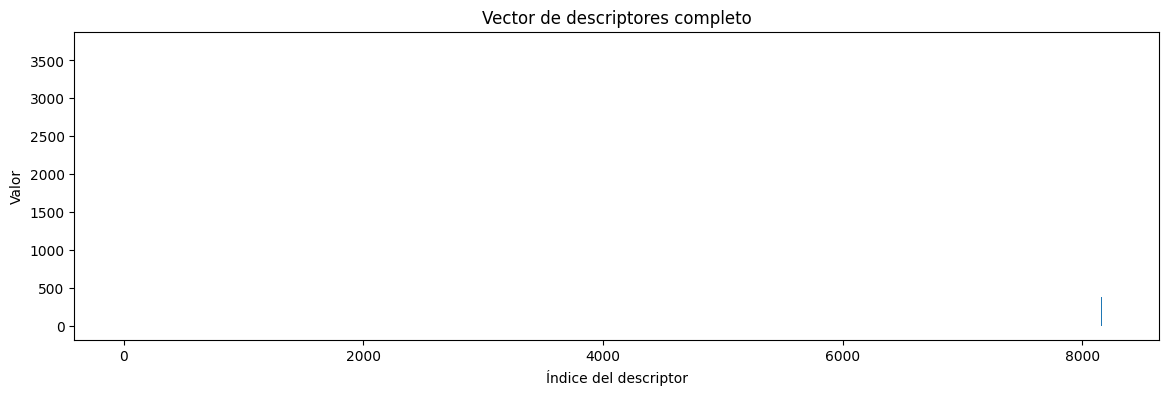

In [17]:
vec = extract_descriptors_completo(img)

plt.figure(figsize=(14,4))
plt.bar(np.arange(len(vec)), vec)
plt.title("Vector de descriptores completo")
plt.xlabel("Índice del descriptor")
plt.ylabel("Valor")
plt.show()


### Separacion y Visualizacion de cada grupo de descriptor

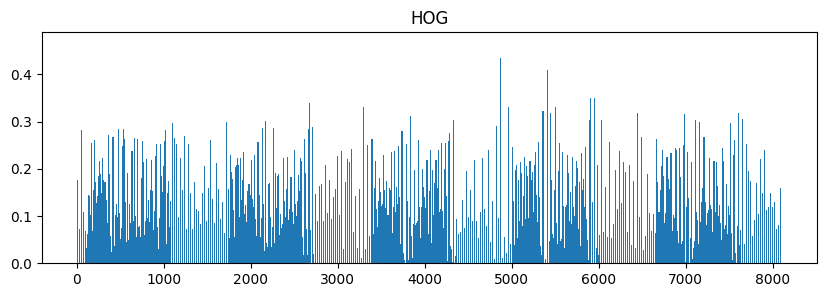

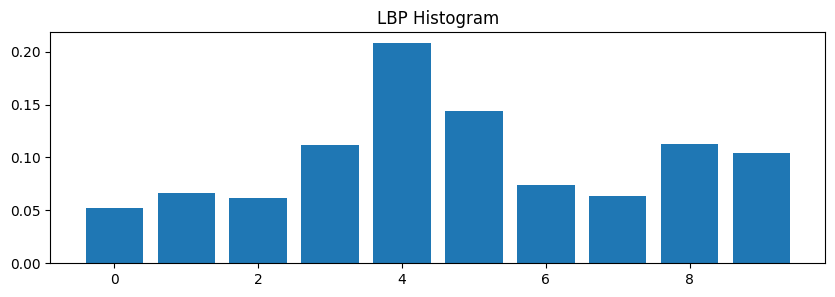

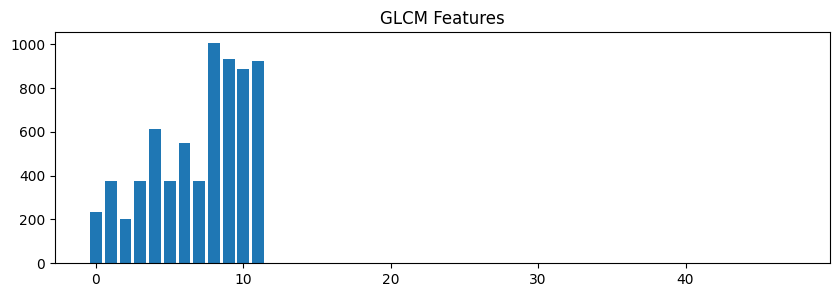

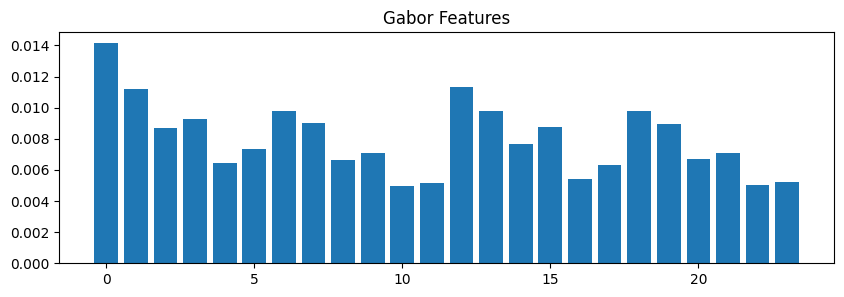

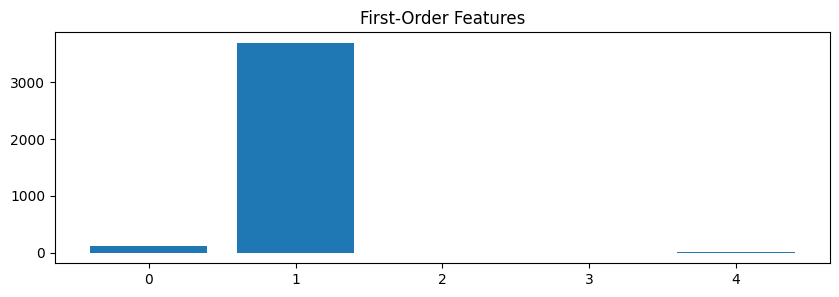

In [18]:
def plot_descriptor(nombre, valores):
    plt.figure(figsize=(10,3))
    plt.bar(np.arange(len(valores)), valores)
    plt.title(nombre)
    plt.show()


hog_feat, _ = descriptor_hog(img)
hu_feat = descriptor_hu(img)
fourier_feat = descriptor_fourier(img)
lbp_hist, _ = descriptor_lbp(img)
glcm_feat = descriptor_glcm(img)
gabor_feat = descriptor_gabor(img)
first_feat = descriptor_primer_orden(img)

plot_descriptor("HOG", hog_feat)
plot_descriptor("LBP Histogram", lbp_hist)
plot_descriptor("GLCM Features", glcm_feat)
plot_descriptor("Gabor Features", gabor_feat)
plot_descriptor("First-Order Features", first_feat)


### Visualización PCA (2D o 3D)

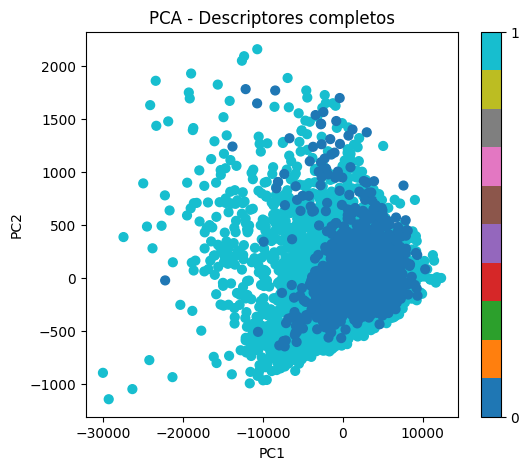

In [22]:
# Para ver si los descriptores separan las clases

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt

# Asumiendo X es tu matriz de descriptores y y tus etiquetas
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train_encoded, cmap="tab10", s=40)
plt.colorbar(scatter, ticks=np.unique(y_train_encoded))
plt.title("PCA - Descriptores completos")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

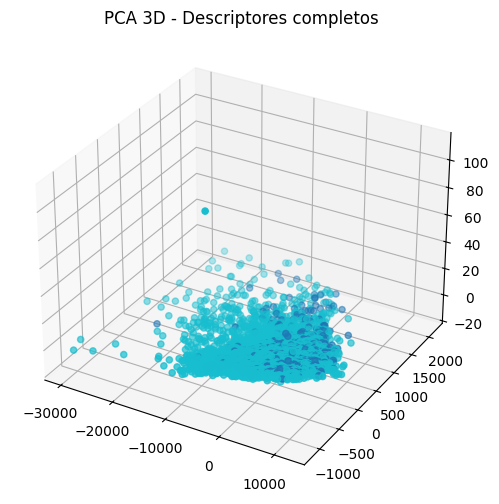

In [23]:
# Visualizacion 3D
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Ensure y_train is encoded if not already done in this scope
# (Assuming y_train and LabelEncoder are defined from previous cells)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=y_train_encoded, cmap='tab10')
ax.set_title("PCA 3D - Descriptores completos")
plt.show()

### Mapa de Calor y correlaciones

/home/david/DavLeonardo/2025-2/DeepThinking-VisionComputadora2025-2/.venv/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/david/DavLeonardo/2025-2/DeepThinking-VisionComputadora2025-2/.venv/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


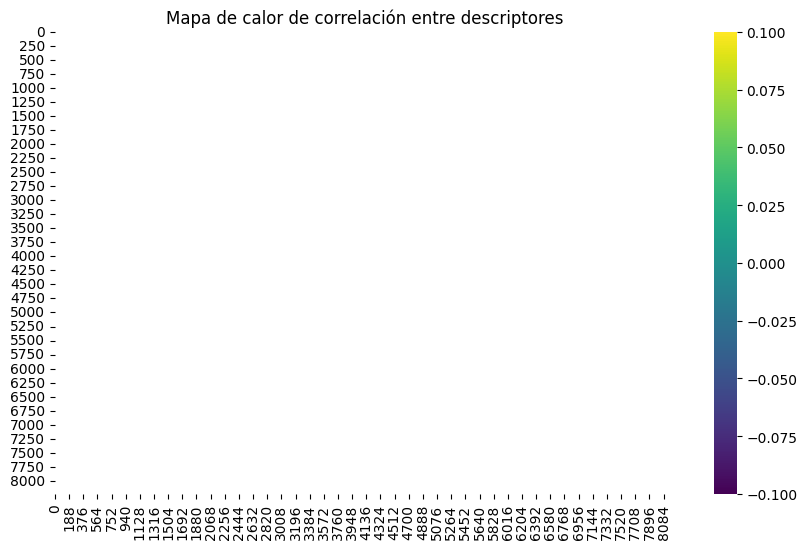

In [24]:
import seaborn as sns
import pandas as pd

vec = extract_descriptors_completo(img)
df = pd.DataFrame(vec).T

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="viridis", annot=False)
plt.title("Mapa de calor de correlación entre descriptores")
plt.show()


### Radar Plot

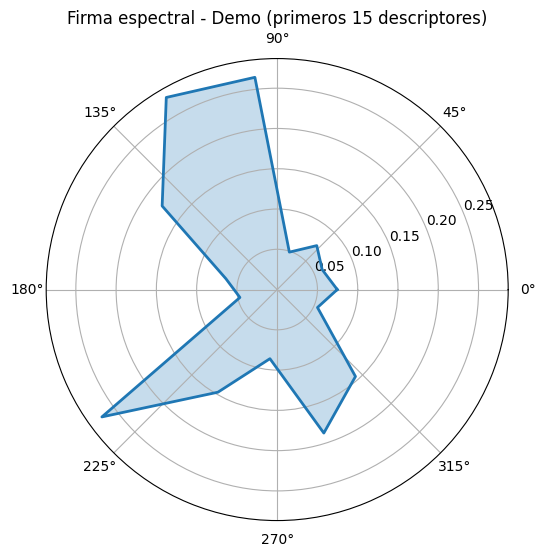

In [25]:
def radar_plot(values, label="Clase"):
    angles = np.linspace(0, 2*np.pi, len(values), endpoint=False)
    values = np.concatenate((values, [values[0]]))
    angles = np.concatenate((angles, [angles[0]]))

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(f"Firma espectral - {label}")
    plt.show()

# ejemplo con 1 imagen
radar_plot(vec[:15], "Demo (primeros 15 descriptores)")


### DASHBOARD COMPLETO

Dimensión del descriptor completo: 8234


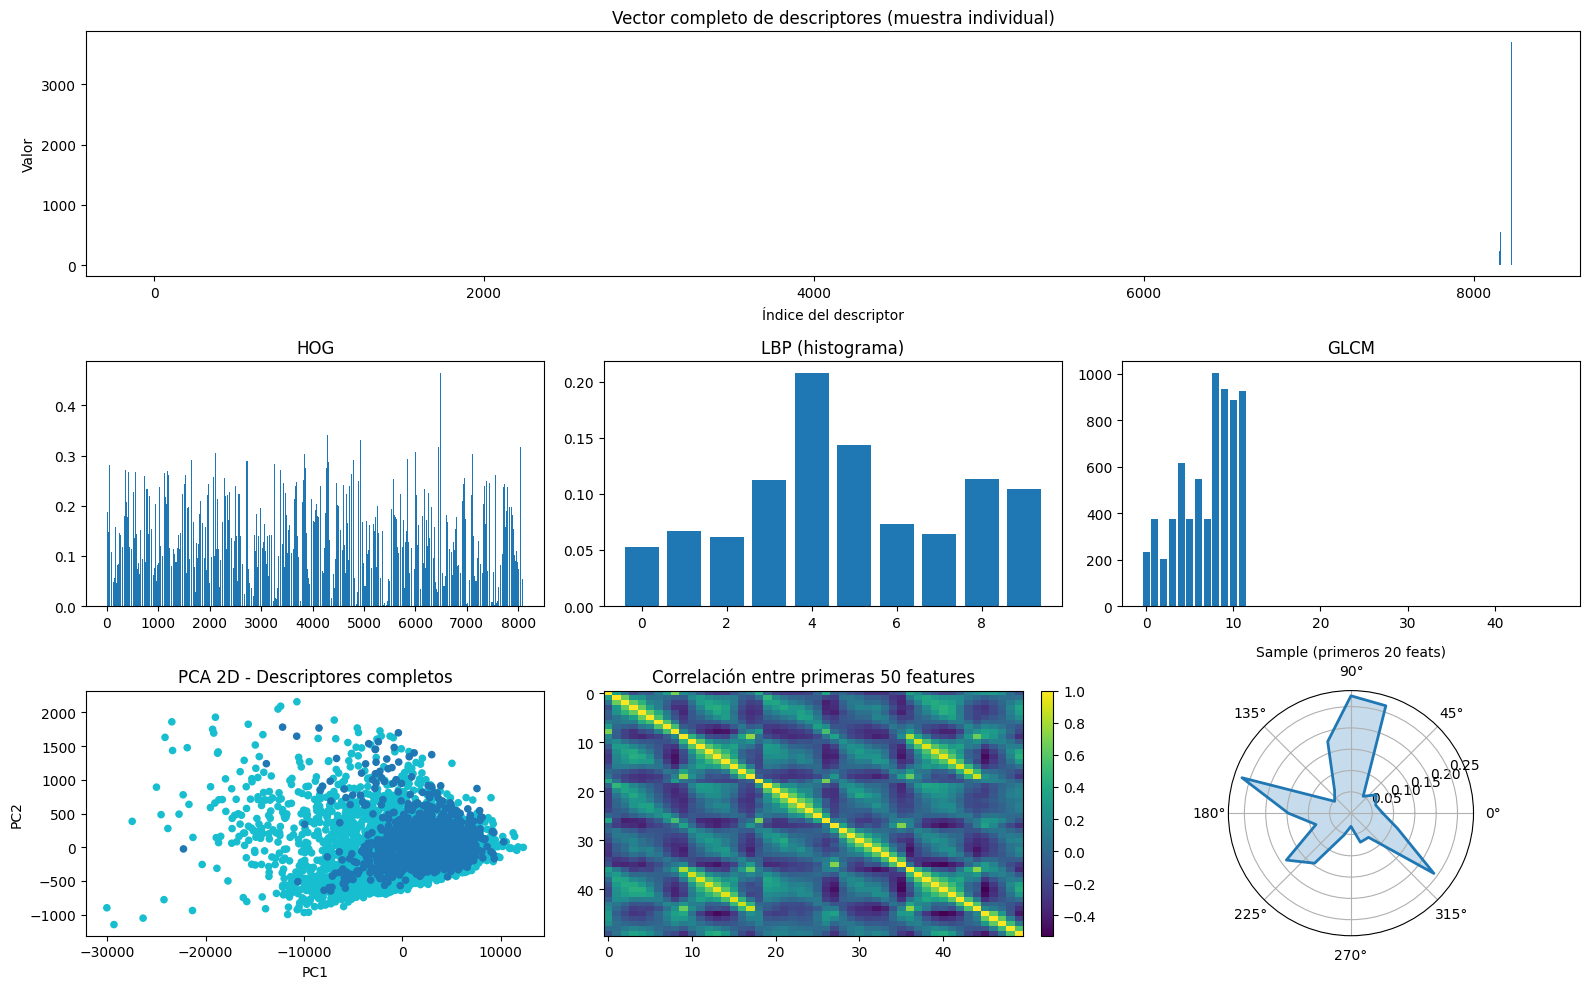

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from matplotlib import cm
from sklearn.preprocessing import LabelEncoder

def radar_plot(values, label="Sample", ax=None):
    """Radar chart simple para los primeros N descriptores."""
    N = len(values)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    values = np.concatenate((values, [values[0]]))
    angles = np.concatenate((angles, [angles[0]]))

    if ax is None:
        ax = plt.subplot(111, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(label, fontsize=10)

def visualizar_dashboard_descriptores(img, X, y, sample_idx=0):
    """
    Dashboard de visualización para extract_descriptors_completo:
    - Vector completo para una imagen
    - Grupos de descriptores (HOG, LBP, GLCM, Gabor, Primer orden)
    - PCA 2D de todo el dataset
    - Mapa de calor de correlaciones (subset)
    - Radar plot (primeros N descriptores)
    """
    # 1) Vector de descriptores de una imagen
    vec = extract_descriptors_completo(img)
    n_feats = len(vec)
    print(f"Dimensión del descriptor completo: {n_feats}")

    # --- Definir índices aproximados por grupo (ajusta si cambiaste algo) ---
    hog_feat, _     = descriptor_hog(img)
    hu_feat         = descriptor_hu(img)
    fourier_feat    = descriptor_fourier(img)
    lbp_hist, _     = descriptor_lbp(img)
    glcm_feat       = descriptor_glcm(img)
    gabor_feat      = descriptor_gabor(img)
    first_feat      = descriptor_primer_orden(img)

    idx0 = 0
    idx_hog_end   = idx0 + len(hog_feat)
    idx_hu_end    = idx_hog_end + len(hu_feat)
    idx_four_end  = idx_hu_end + len(fourier_feat)
    idx_lbp_end   = idx_four_end + len(lbp_hist)
    idx_glcm_end  = idx_lbp_end + len(glcm_feat)
    idx_gabor_end = idx_glcm_end + len(gabor_feat)
    idx_first_end = idx_gabor_end + len(first_feat)

    # 2) PCA 2D sobre todo el dataset
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # 3) Correlación (subset de features para que sea legible)
    max_feats_corr = min(50, X.shape[1])  # primeras 50
    corr = np.corrcoef(X[:, :max_feats_corr].T)

    # ---------------- FIGURA PRINCIPAL ----------------
    plt.figure(figsize=(16, 10))
    gs = plt.GridSpec(3, 3, figure=plt.gcf())

    # (A) Vector completo
    ax1 = plt.subplot(gs[0, :])
    ax1.bar(np.arange(n_feats), vec, width=1)
    ax1.set_title("Vector completo de descriptores (muestra individual)")
    ax1.set_xlabel("Índice del descriptor")
    ax1.set_ylabel("Valor")

    # (B) Grupos de descriptores
    ax2 = plt.subplot(gs[1, 0])
    ax2.bar(np.arange(len(hog_feat)), vec[idx0:idx_hog_end])
    ax2.set_title("HOG")

    ax3 = plt.subplot(gs[1, 1])
    ax3.bar(np.arange(len(lbp_hist)), vec[idx_four_end:idx_lbp_end])
    ax3.set_title("LBP (histograma)")

    ax4 = plt.subplot(gs[1, 2])
    ax4.bar(np.arange(len(glcm_feat)), vec[idx_lbp_end:idx_glcm_end])
    ax4.set_title("GLCM")

    # (C) PCA 2D
    ax5 = plt.subplot(gs[2, 0])
    scatter = ax5.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=20)
    ax5.set_title("PCA 2D - Descriptores completos")
    ax5.set_xlabel("PC1")
    ax5.set_ylabel("PC2")

    # (D) Heatmap de correlaciones
    ax6 = plt.subplot(gs[2, 1])
    cax = ax6.imshow(corr, aspect='auto', cmap=cm.viridis)
    ax6.set_title(f"Correlación entre primeras {max_feats_corr} features")
    plt.colorbar(cax, ax=ax6, fraction=0.046, pad=0.04)

    # (E) Radar plot (primeros N descriptores)
    ax7 = plt.subplot(gs[2, 2], projection='polar')
    N_radar = min(20, n_feats)  # recorta para que no sea ilegible
    radar_plot(vec[:N_radar], label="Sample (primeros 20 feats)", ax=ax7)

    plt.tight_layout()
    plt.show()


# ===== Ejemplo de uso =====
# img: imagen en gris de tu dataset
# X, y    : matriz de descriptores y etiquetas que ya calculaste

# Ensure y_train is encoded if not already done in this scope
# (Assuming y_train and LabelEncoder are defined from previous cells)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

visualizar_dashboard_descriptores(img, X_train, y_train_encoded)
